# Notebook 2. Masked Prediction: MAE on UCR Time Series

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/time_series/02_masking_mae.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026 -- *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 3.3 -- Masked prediction (time series) - Instantiates the lecture part, Section 1.5

---

**Mechanism: masked reconstruction.** Hide a random subset of the patches of a series and ask
the model to reconstruct exactly the hidden ones. No labels, no negatives, no teacher -- the
supervision is the data's own withheld content.

This is MAE (He et al., 2022) applied to sequences, which is also how **PatchTST**'s
self-supervised variant (Nie et al., 2023) and **TST** (Zerveas et al., 2021) pretrain.

### Why masking is a natural fit for time series

An image patch can often be guessed from texture continuity. A masked *time* span is different:
to fill it you need whatever periodic or morphological regularity the series obeys. For a leaf
outline that means the lobe pattern; for an ECG, the beat structure. That is exactly the
structure a classifier needs, which is why masked prediction transfers.

$$
\mathcal{L} = \frac{1}{|\Omega|} \sum_{p \in \Omega} \left\| \hat{x}_p - \tilde{x}_p \right\|_2^2,
\qquad \Omega = \{p : \text{mask}_p = 1\}
$$

In [1]:
## Standard libraries
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "time_series")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_ts.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_ts.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/time_series/tutorial_ts.py", "tutorial_ts.py")

from tutorial_ts import (
    seed_everything, get_device, setup_plotting,
    TARGET_DATASET, SERIES_LEN, PATCH_LEN, PATCH_STRIDE,
    UCRDataset, UCRCorpusDataset, ucr_class_names,
    TransformerBlock, build_ts_encoder, try_load_checkpoint,
    plot_curve, plot_embedding_scatter, extract_features, linear_probe_accuracy,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)

DATA_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/time_series/checkpoints"
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

NUM_PATCHES = (SERIES_LEN - PATCH_LEN) // PATCH_STRIDE + 1
print(f"{SERIES_LEN} steps / patch {PATCH_LEN} -> {NUM_PATCHES} patches")

Device: cuda:0
128 steps / patch 16 -> 8 patches


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights live in this repository (Git LFS). Locally they are already on disk; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_ts_encoder.pt", "mae_ts_encoder.pt", "dino_ts_encoder.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://media.githubusercontent.com/media/{_REPO}/main/artifacts/time_series/checkpoints/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "time_series", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Data and patchify

MAE needs no augmentation at all -- the masking *is* the pretext task. We feed the raw pooled
UCR corpus and define `patchify` / `unpatchify` helpers to move between a series and its
non-overlapping patches.

In [3]:
train_corpus = UCRCorpusDataset(DATA_PATH, per_dataset_cap=2000)
train_loader = data.DataLoader(train_corpus, batch_size=256, shuffle=True, drop_last=True,
                               num_workers=0, pin_memory=True)
print(f"\nMAE training pool: {len(train_corpus)} series (labels discarded)")


def patchify(x, patch_len=PATCH_LEN, stride=PATCH_STRIDE):
    '''(B, L, C) -> (B, C, num_patches, patch_len)'''
    x = x.permute(0, 2, 1)  # (B, C, L)
    patches = x.unfold(dimension=-1, size=patch_len, step=stride)
    return patches.contiguous()


def unpatchify(patches, stride=PATCH_STRIDE):
    '''(B, C, num_patches, patch_len) -> (B, L, C). Assumes stride == patch_len.'''
    B, C, P, plen = patches.shape
    x = patches.reshape(B, C, P * plen)
    return x.permute(0, 2, 1)

UCR pretraining corpus: 45192 series from 128 datasets

MAE training pool: 45192 series (labels discarded)


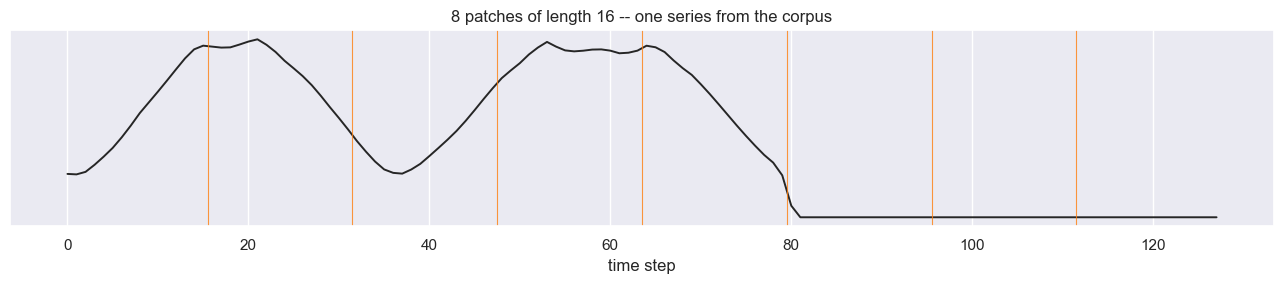

patchify/unpatchify round-trip max abs error: 0.0
patch tensor shape: (1, 1, 8, 16)


In [4]:
# Visualize the patch grid on one series
sample = train_corpus[len(train_corpus) // 2]  # (128, 1)
series = sample[:, 0].numpy()

plt.figure(figsize=(13, 3))
plt.plot(series, color="0.15", linewidth=1.4)
for p in range(1, NUM_PATCHES):
    plt.axvline(p * PATCH_STRIDE - 0.5, color="tab:orange", linewidth=0.8, alpha=0.8)
plt.title(f"{NUM_PATCHES} patches of length {PATCH_LEN} -- one series from the corpus")
plt.xlabel("time step"); plt.yticks([])
plt.tight_layout(); plt.show(); plt.close()

# Round-trip check
p = patchify(sample.unsqueeze(0))
r = unpatchify(p)
print("patchify/unpatchify round-trip max abs error:", (r - sample.unsqueeze(0)).abs().max().item())
print("patch tensor shape:", tuple(p.shape))

## Random masking

The cell below performs per-sample random masking. The trick (from the MAE reference
implementation) is to sort uniform noise: the first `len_keep` entries of that sorted order
are the visible patches, and `argsort` of the sort gives the permutation that restores
original order.

<div class="alert alert-info">

**Why the double argsort:** `noise = torch.rand(B, N)`, then `ids_shuffle = argsort(noise)`,
then `ids_restore = argsort(ids_shuffle)`, which is the inverse permutation. So `mask` can be
built as zeros-then-ones in *shuffled* order and `gather`ed back with `ids_restore`. Sorting
noise draws a different random subset per sample without any Python-level loop. This is the
*same* cell as the remote sensing notebook 2.

</div>

In [5]:
def random_masking(x, mask_ratio):
    '''
    x: (B, N, D) patch embeddings (channels folded into B; pre pos-embed, pre [CLS]).
    Returns:
      x_visible:   (B, len_keep, D) -- only the visible patches
      mask:        (B, N) -- 0 for visible, 1 for masked (ORIGINAL patch order)
      ids_restore: (B, N) -- permutation restoring original patch order
      ids_keep:    (B, len_keep) -- original patch index of each visible token
    '''
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    # --- SOLUTION START (random_masking) ---
    noise = torch.rand(B, N, device=x.device)

    ids_shuffle = torch.argsort(noise, dim=1)        # ascending: small noise = keep
    ids_restore = torch.argsort(ids_shuffle, dim=1)   # inverse permutation

    ids_keep = ids_shuffle[:, :len_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)  # unshuffle to original order
    # --- SOLUTION END ---
    return x_visible, mask, ids_restore, ids_keep


_x = torch.randn(2, NUM_PATCHES, 8)
_vis, _mask, _restore, _keep = random_masking(_x, mask_ratio=0.5)
print("visible shape:", tuple(_vis.shape), "| expected:", (2, NUM_PATCHES // 2, 8))
print("mask ratio:", _mask.mean().item(), "| expected ~0.5")

visible shape: (2, 4, 8) | expected: (2, 4, 8)
mask ratio: 0.5 | expected ~0.5


## Model: asymmetric encoder-decoder

The **encoder** is our shared patch Transformer, but it only ever sees the visible patches --
that asymmetry is what makes MAE efficient. The **decoder** is intentionally shallow and narrow;
its only job is to map encoded visible tokens plus mask tokens back to patch values. After
pretraining we throw the decoder away and keep only the encoder.

In [6]:
class MAETSModel(nn.Module):
    def __init__(self, encoder, decoder_dim=64, decoder_depth=2, decoder_heads=4,
                 patch_len=PATCH_LEN, num_patches=NUM_PATCHES):
        super().__init__()
        self.encoder = encoder
        self.patch_len = patch_len
        self.num_patches = num_patches
        embed_dim = encoder.embed_dim

        self.decoder_embed = nn.Linear(embed_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_dim))
        self.decoder_blocks = nn.ModuleList(
            [TransformerBlock(decoder_dim, decoder_heads) for _ in range(decoder_depth)]
        )
        self.decoder_norm = nn.LayerNorm(decoder_dim)
        self.decoder_pred = nn.Linear(decoder_dim, patch_len)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward_encoder(self, imgs, mask_ratio):
        # imgs: (B, L, C) -> channel-independent (B*C, L)
        B, L, C = imgs.shape
        x = imgs.permute(0, 2, 1).reshape(B * C, L)
        x = self.encoder.patch_embed(x)  # (B*C, N, D)
        x_visible, mask, ids_restore, ids_keep = random_masking(x, mask_ratio)

        cls_tokens = self.encoder.cls_token.expand(x.shape[0], -1, -1)
        # each visible token's OWN patch position (x_visible is in ids_keep order)
        pos_visible = torch.gather(
            self.encoder.pos_embed[:, 1:, :].expand(x.shape[0], -1, -1), dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        )
        tokens = torch.cat(
            [cls_tokens + self.encoder.pos_embed[:, :1, :], x_visible + pos_visible], dim=1
        )
        for block in self.encoder.blocks:
            tokens = block(tokens)
        tokens = self.encoder.norm(tokens)
        return tokens, mask, ids_restore

    def forward_decoder(self, tokens, ids_restore):
        x = self.decoder_embed(tokens)  # (B*C, 1+len_keep, decoder_dim)
        B, N_plus1 = x.shape[0], ids_restore.shape[1] + 1
        mask_tokens = self.mask_token.expand(B, N_plus1 - x.shape[1], -1)
        x_no_cls = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_no_cls = torch.gather(
            x_no_cls, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, x_no_cls.shape[-1])
        )
        x = torch.cat([x[:, :1, :], x_no_cls], dim=1)
        x = x + self.decoder_pos_embed
        for block in self.decoder_blocks:
            x = block(x)
        x = self.decoder_norm(x)
        pred = self.decoder_pred(x[:, 1:, :])  # (B*C, N, patch_len)
        return pred

    def forward(self, imgs, mask_ratio=0.5):
        B, L, C = imgs.shape
        tokens, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(tokens, ids_restore)
        pred = pred.reshape(B, C, self.num_patches, self.patch_len)
        mask = mask.reshape(B, C, self.num_patches)
        return pred, mask

## Reconstruction loss

The cell below computes the masked-only $\ell_2$ reconstruction loss over the **masked**
patches only.

<div class="alert alert-warning">

**Per-patch target normalization -- the same detail that decided whether MAE worked in the remote sensing part.**
$\tilde{x}_p$ is not the raw patch: it is each target patch standardized by *its own* mean and
variance before the MSE (He et al., 2022, Sec. 3).

Without it, the loss is dominated by each patch's mean level -- one number the decoder can guess
from its neighbors while the encoder learns nothing about *shape*. Our series are already
z-normalized as a whole, but that says nothing about any individual patch's local offset;
normalizing per patch removes that too, forcing the encoder to represent within-patch and
cross-patch **morphology**. We build it in from the start via `norm_pix`.

</div>

In [7]:
def mae_reconstruction_loss(pred, imgs, mask, norm_pix=True):
    '''
    pred: (B, C, N, patch_len) predicted patches
    imgs: (B, L, C) original series
    mask: (B, C, N) 1 for masked (loss applies), 0 for visible (ignored)
    norm_pix: standardize each target patch by its own mean/var before the MSE.
    '''
    # --- SOLUTION START (mae_loss) ---
    target = patchify(imgs)  # (B, C, N, patch_len)

    if norm_pix:
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1.0e-6).sqrt()

    loss_per_patch = ((pred - target) ** 2).mean(dim=-1)  # (B, C, N)
    loss = (loss_per_patch * mask).sum() / mask.sum()
    # --- SOLUTION END ---
    return loss

## Live training (dynamics only)

<div class="alert alert-info">

**Choosing the mask ratio.** Image MAE masks 75%, but a 128-step series gives only **8** patch
tokens. At 75% just 2 tokens would remain visible -- too little context for the task to be
learnable. We use **0.5**, keeping 4 visible: enough to anchor the reconstruction, few enough
that filling the gaps demands real structure.

This is a concrete instance of a general point: SSL hyperparameters are not universal
constants, they are functions of the token budget the modality provides.

</div>

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 1/300 [00:00<01:27,  3.40it/s]

  2%|▏         | 5/300 [00:00<00:20, 14.28it/s]

  3%|▎         | 9/300 [00:00<00:13, 21.14it/s]

  4%|▍         | 13/300 [00:00<00:11, 25.05it/s]

...

 96%|█████████▋| 289/300 [00:08<00:00, 34.37it/s]

 98%|█████████▊| 293/300 [00:09<00:00, 34.33it/s]

 99%|█████████▉| 297/300 [00:09<00:00, 34.47it/s]

100%|██████████| 300/300 [00:09<00:00, 32.57it/s]

masked reconstruction MSE 1.1673 -> 0.6662


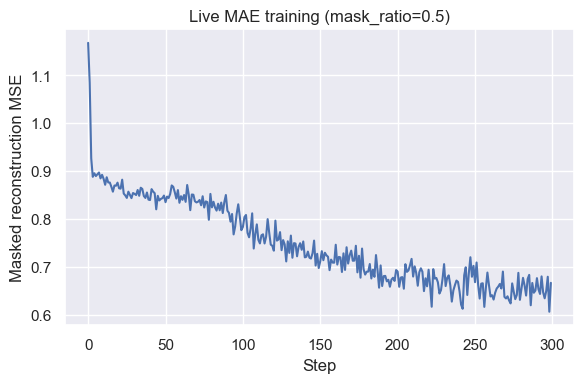

In [8]:
MASK_RATIO = 0.5
NUM_STEPS = 300

mae_model = MAETSModel(build_ts_encoder()).to(device)
optimizer = optim.AdamW(mae_model.parameters(), lr=5e-4, weight_decay=1e-4)

loss_history = []
data_iter = iter(train_loader)
mae_model.train()

for step in tqdm(range(NUM_STEPS)):
    try:
        series_batch = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        series_batch = next(data_iter)
    series_batch = series_batch.to(device)

    pred, mask = mae_model(series_batch, mask_ratio=MASK_RATIO)
    loss = mae_reconstruction_loss(pred, series_batch, mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"masked reconstruction MSE {loss_history[0]:.4f} -> {loss_history[-1]:.4f}")
plot_curve(loss_history, xlabel="Step", ylabel="Masked reconstruction MSE",
           title=f"Live MAE training (mask_ratio={MASK_RATIO})")

## Loading the pretrained encoder

In [9]:
pretrained_mae = MAETSModel(build_ts_encoder()).to(device)
found = try_load_checkpoint(pretrained_mae.encoder, CHECKPOINT_PATH,
                            "mae_ts_encoder.pt", device)
if not found:
    print("Falling back to the briefly-trained model from the live-training cell above.")
    pretrained_mae = mae_model

pretrained_mae.eval()
mae_encoder = pretrained_mae.encoder
for p in mae_encoder.parameters():
    p.requires_grad = False

Found pretrained model at ../../artifacts/time_series/checkpoints\mae_ts_encoder.pt, loading...


## The MAE signature visual: visible input -> reconstruction -> original

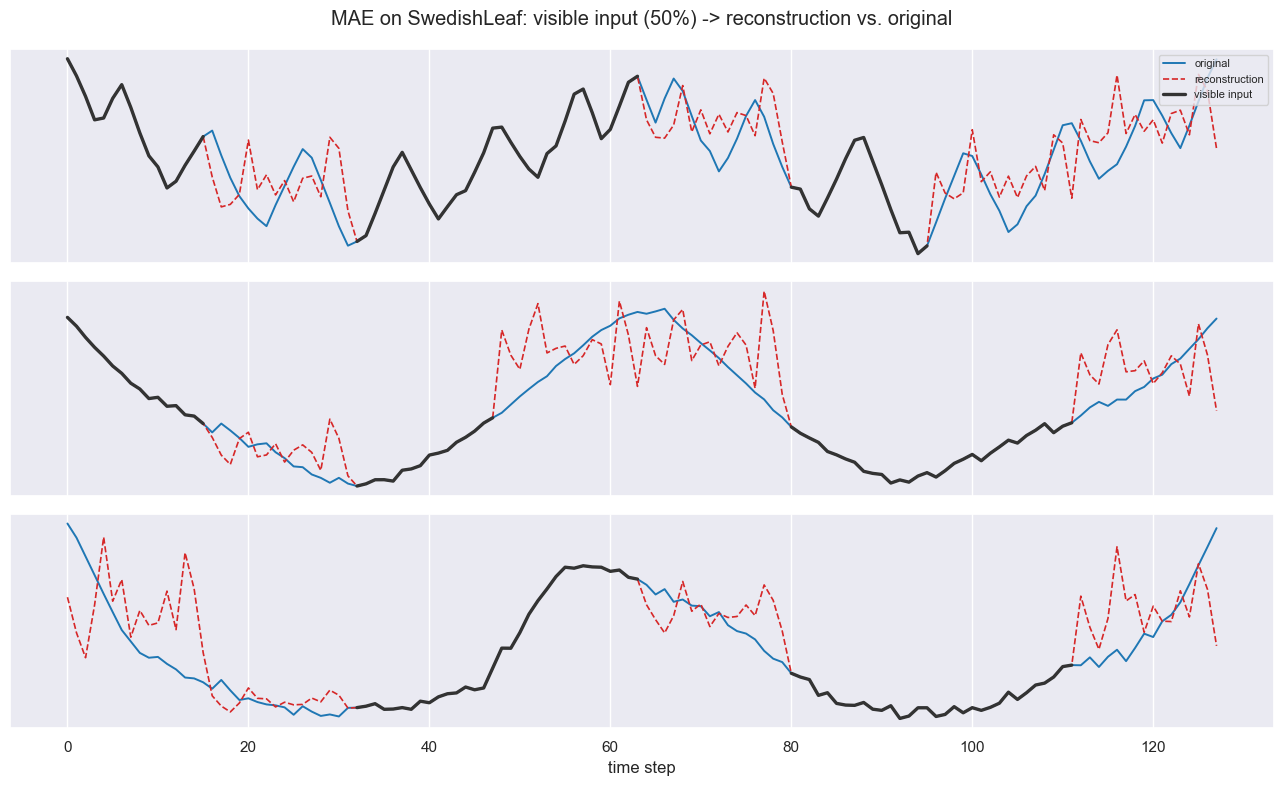

In [10]:
@torch.no_grad()
def visualize_reconstruction(model, series_batch, mask_ratio=0.5, norm_pix=True):
    pred, mask = model(series_batch, mask_ratio=mask_ratio)   # (B,C,N,plen), (B,C,N)
    target = patchify(series_batch)

    if norm_pix:
        mean = target.mean(dim=-1, keepdim=True)
        std = (target.var(dim=-1, keepdim=True) + 1e-6).sqrt()
        pred = pred * std + mean

    masked_patches = target.clone()
    masked_patches[mask.bool()] = float("nan")     # NaN -> masked spans are gaps in the plot
    masked_series = unpatchify(masked_patches)

    recon_patches = torch.where(mask.unsqueeze(-1).bool(), pred, target)
    recon_series = unpatchify(recon_patches)
    return masked_series, recon_series


# Show reconstructions on the downstream dataset, which is more interpretable than a random
# corpus member: these are leaf-outline traces.
target_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "test")
sample_series = torch.stack([target_ds[k * 41][0] for k in range(3)]).to(device)
masked_series, recon_series = visualize_reconstruction(pretrained_mae, sample_series, MASK_RATIO)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(sample_series[k, :, 0].cpu(), color="tab:blue", label="original", linewidth=1.4)
    ax.plot(recon_series[k, :, 0].cpu(), color="tab:red", linestyle="--",
            label="reconstruction", linewidth=1.2)
    ax.plot(masked_series[k, :, 0].cpu(), color="0.2", label="visible input", linewidth=2.4)
    ax.set_yticks([])
    if k == 0:
        ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time step")
fig.suptitle(f"MAE on {TARGET_DATASET}: visible input ({int(100*(1-MASK_RATIO))}%) "
             f"-> reconstruction vs. original")
plt.tight_layout(); plt.show(); plt.close()

## Does it classify? The frozen linear probe

The same probe as Notebook 1, but here the **readout itself is a question worth asking**.

MAE's loss lives entirely on the patch tokens: the `[CLS]` token is never supervised by
anything. The standard conclusion -- and what the remote sensing part finds for image MAE -- is that mean-pooling
the patch tokens is therefore the honest way to read an MAE encoder, and that a `[CLS]` probe
understates it. That reasoning is why `forward_features` takes a `pool` argument at all.

Rather than assert the outcome, the cell below simply **measures both** and prints them. Compare
the gap here with what you saw in Notebook 1, where `[CLS]` *is* directly trained.

In [11]:
train_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "train")
test_ds  = UCRDataset(DATA_PATH, TARGET_DATASET, "test")
class_names = ucr_class_names(DATA_PATH, TARGET_DATASET)

mae_probe = {}
for pool in ("cls", "mean"):
    tr_f, tr_y = extract_features(mae_encoder, train_ds, device, pool=pool)
    te_f, te_y = extract_features(mae_encoder, test_ds,  device, pool=pool)
    mae_probe[pool] = linear_probe_accuracy(tr_f, tr_y, te_f, te_y)
    print(f"MAE frozen probe, pool={pool:>4s}: {mae_probe[pool]:.4f}")

better = max(mae_probe, key=mae_probe.get)
print(f"\nbetter readout here: pool={better} "
      f"(gap {abs(mae_probe['mean'] - mae_probe['cls']):.4f})")
print("The point is that the readout is a *choice* that changes the number --")
print("so it has to be reported, not left implicit.")

MAE frozen probe, pool= cls: 0.9072
MAE frozen probe, pool=mean: 0.8816

better readout here: pool=cls (gap 0.0256)
The point is that the readout is a *choice* that changes the number --
so it has to be reported, not left implicit.


## Embedding geometry: t-SNE of the MAE features

Notebooks 1 and 3 end their probe section with the same projection, so the three mechanisms can
be compared by eye and not only by accuracy. Note which readout is used here: the features are
re-extracted with the better-scoring pool above, so the picture and the number describe the same
representation.

MAE is the interesting case. Its loss only ever asks for pixel-accurate reconstruction, never
for class structure, so whatever separation appears here is a side effect of learning to predict
masked patches.

In [ ]:
from sklearn.manifold import TSNE

# Re-extract with the better readout so the scatter matches the accuracy printed above.
te_f_best, te_y_best = extract_features(mae_encoder, test_ds, device, pool=better)

tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
embedding_2d = tsne.fit_transform(te_f_best)

plot_embedding_scatter(embedding_2d, te_y_best, class_names=class_names,
                       title=f"t-SNE of MAE embeddings (pool={better}) -- {TARGET_DATASET} test series")

## The shortcut failure mode: low mask ratio -> trivial interpolation

<div class="alert alert-info">

**Why 0.5 and not, say, 0.1?** If too few patches are hidden, the model fills each gap by
interpolating from immediate neighbors without learning anything about the series' global
structure -- a shortcut. Below, at a much lower mask ratio, reconstructions track the truth
closely (low MSE) even though the representation task was never forced to be hard.

</div>

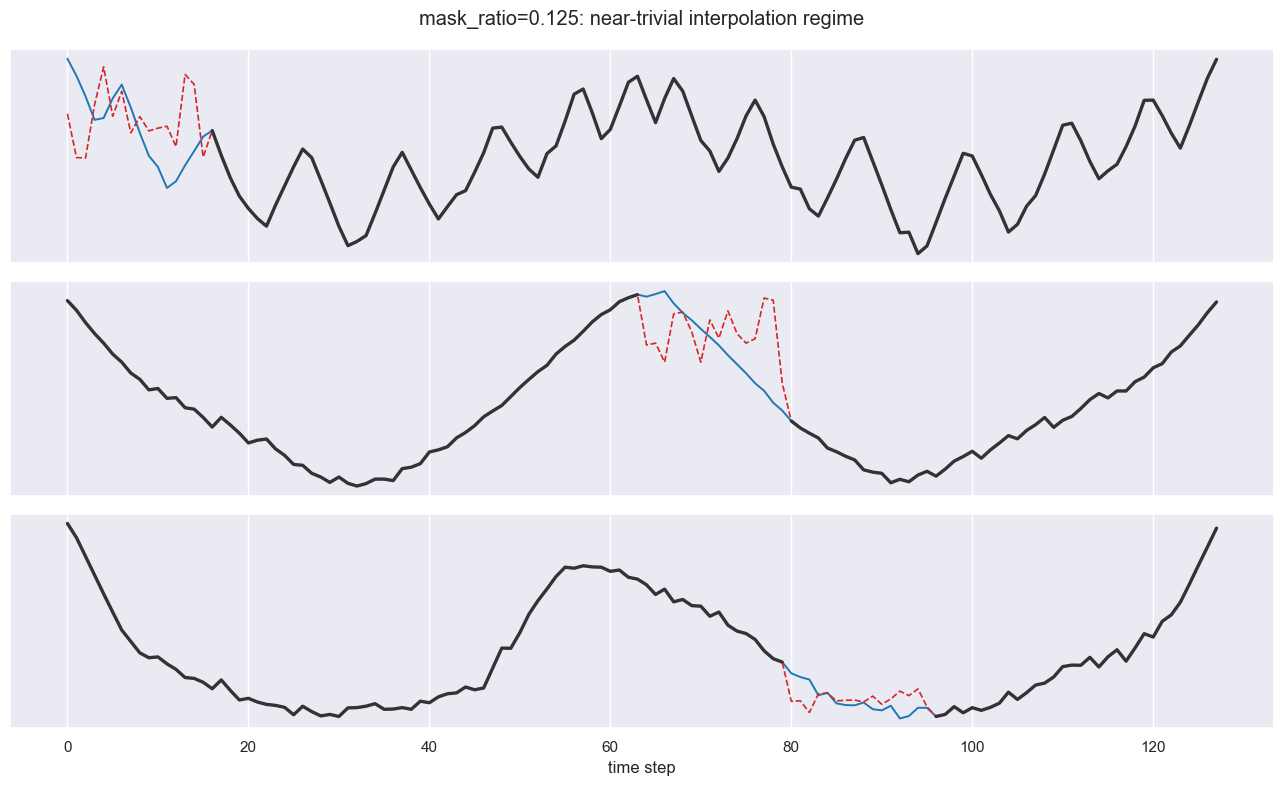

In [12]:
LOW_MASK_RATIO = 0.125   # 1 of 8 patches

masked_low, recon_low = visualize_reconstruction(pretrained_mae, sample_series, LOW_MASK_RATIO)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(sample_series[k, :, 0].cpu(), color="tab:blue", linewidth=1.4)
    ax.plot(recon_low[k, :, 0].cpu(), color="tab:red", linestyle="--", linewidth=1.2)
    ax.plot(masked_low[k, :, 0].cpu(), color="0.2", linewidth=2.4)
    ax.set_yticks([])
axes[-1].set_xlabel("time step")
fig.suptitle(f"mask_ratio={LOW_MASK_RATIO}: near-trivial interpolation regime")
plt.tight_layout(); plt.show(); plt.close()

## Discussion: the reconstruction-representation gap

Low patch-reconstruction error does **not** guarantee a useful representation. A model that
learns to interpolate never has to represent the global morphology that classification depends
on. This is the **reconstruction <-> representation gap**, and it is the single most important
idea in this notebook: *the pretext loss is not the thing you care about*. You can drive it
down smoothly while the representation barely improves.

Two design choices are what keep the gap narrow here:

1. **A high enough mask ratio** that interpolation is not sufficient (0.5 on 8 tokens).
2. **Per-patch target normalization**, which removes the easy per-patch level signal and forces
   the encoder to spend capacity on relative structure.

In the remote sensing part the offline MAE encoder scored barely above a random network on the EuroSAT probe
until this normalization was added -- the pretext loss looked *fine* the whole time. The flag
`src/time_series/pretraining/train_mae_ts.py --no-norm-pix` reproduces the failure mode here,
and Notebook 4 puts the resulting probe numbers side by side.

### References

- He, K., Chen, X., Xie, S., Li, Y., Dollar, P., & Girshick, R. (2022). *Masked Autoencoders
  Are Scalable Vision Learners (MAE).* CVPR.
- Nie, Y. et al. (2023). *A Time Series is Worth 64 Words: Long-term Forecasting with
  Transformers (PatchTST).* ICLR.
- Zerveas, G. et al. (2021). *A Transformer-based Framework for Multivariate Time Series
  Representation Learning (TST).* KDD.
- Devlin, J. et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for
  Language Understanding.* NAACL.